In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv(r"C:\Users\mrak5\Downloads\Bank Customer Churn Prediction .csv")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [10]:
df.shape

(10000, 12)

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48
churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.columns = [c.strip().lower() for c in df.columns]


In [ ]:
# Convert incorrect data types
num_cols = ['credit_score','age','tenure','balance','products_number','credit_card','active_member','estimated_salary','churn']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
# Lets Create Age Groups
bins =[0,29,45,60,200]
label = ['Young','Adult','Mature','Senior']
df['Age_Group'] = pd.cut(df['age'], bins=bins, labels=label)

In [ ]:
df['churn_out'] = df['churn'].apply(lambda x: 'Yes' if x == 1 else 'No')

In [ ]:
# Checking new age group
df.head(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,Age_Group,churn_out
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Yes
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,No
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,Yes
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,No
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,No


In [ ]:
bins =[-1,0,50000,120000,df['balance'].max()+1]
label = ['No balance','Low','Medium','High']
df['Balance_Category'] = pd.cut(df['balance'], bins=bins, labels=label)

In [ ]:
df.head(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,Age_Group,churn_out,Balance_Category
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Yes,No balance
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,No,Medium
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,Yes,High
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,No,No balance
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,No,High


In [ ]:
bins = [0,579,669,799,1000]
labels = ['High Risk','Medium Risk','Low Risk','Very Low Risk']
df['Credit_Score_Risk'] = pd.cut(df['credit_score'], bins=bins, labels=labels)

In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,Age_Group,churn_out,Balance_Category,Credit_Score_Risk
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Yes,No balance,Medium Risk
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,No,Medium,Medium Risk
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,Yes,High,High Risk
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,No,No balance,Low Risk
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,No,High,Very Low Risk


In [ ]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[-1,3,7,100],
                            labels=['New Customer','Mid-Term','Long-Term'])


In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,Age_Group,churn_out,Balance_Category,Credit_Score_Risk,tenure_group
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Yes,No balance,Medium Risk,New Customer
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,No,Medium,Medium Risk,New Customer
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,Yes,High,High Risk,Long-Term
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,No,No balance,Low Risk,New Customer
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,No,High,Very Low Risk,New Customer


In [ ]:
def prod_cat(x):
    if x == 1: return 'Single product'
    elif x == 2: return 'Muti product'
    else: return 'High Engagement'
df['products_category'] = df['products_number'].apply(prod_cat)

In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,Age_Group,churn_out,Balance_Category,Credit_Score_Risk,tenure_group,products_category
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Yes,No balance,Medium Risk,New Customer,Single product
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,No,Medium,Medium Risk,New Customer,Single product
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,Yes,High,High Risk,Long-Term,High Engagement
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,No,No balance,Low Risk,New Customer,Muti product
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,No,High,Very Low Risk,New Customer,Single product


In [ ]:
df.groupby('country')['churn'].mean()

country
France     0.161548
Germany    0.324432
Spain      0.166734
Name: churn, dtype: float64

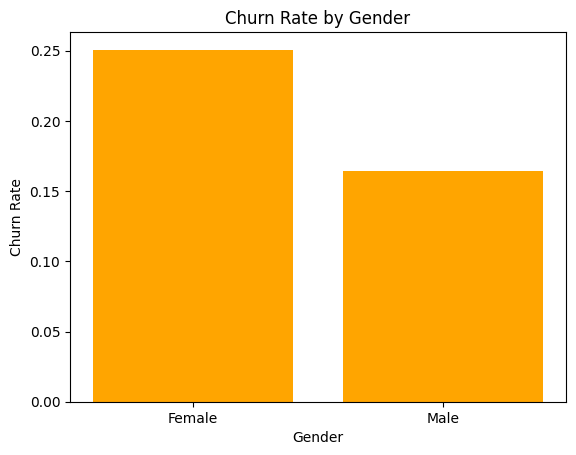

In [ ]:
GenderBy_churn=df.groupby('gender')['churn'].agg(['count','mean'])
GenderBy_churn

plt.bar(GenderBy_churn.index,GenderBy_churn['mean'] ,color='orange')
plt.title('Churn Rate by Gender')
plt.xlabel("Gender")
plt.ylabel("Churn Rate")
plt.show()

Female customers have a higher churn rate at approximately 25%.
Male customers have a lower churn rate at around 17%.
This indicates that female customers are more likely to leave the service compared to males.
Retention initiatives may need to focus more on improving satisfaction and engagement among female customers.

Age_Group
Mature    0.511233
Senior    0.247845
Adult     0.153009
Young     0.075564
Name: churn, dtype: float64


C:\Users\mrak5\AppData\Local\Temp\ipykernel_20168\3909826369.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  GenderBy_Age_Group = df.groupby('Age_Group')['churn'].mean().sort_values(ascending=False)


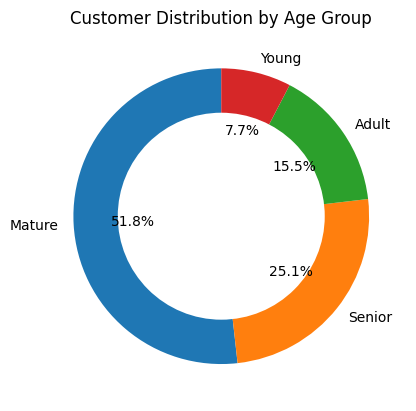

In [ ]:
GenderBy_Age_Group = df.groupby('Age_Group')['churn'].mean().sort_values(ascending=False)
print(GenderBy_Age_Group)
# Dounut Chart
plt.pie(
    GenderBy_Age_Group,
    labels=GenderBy_Age_Group.index,
    autopct='%1.1f%%',
    startangle=90
)

# Create dount table hole
centre_circle = plt.Circle((0,0),0.7, fc='white')
fig= plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Customer Distribution by Age Group')
plt.show()

Mature customers represent the largest portion of the customer base at 51.8%.
Senior customers form the second largest group at 25.1%.
Adult customers account for 15.5% of total customers.
Young customers make up only 7.7% of the customer base, indicating a small younger demographic.

products_category
High Engagement    0.858896
Muti product       0.075817
Single product     0.277144
Name: churn, dtype: float64


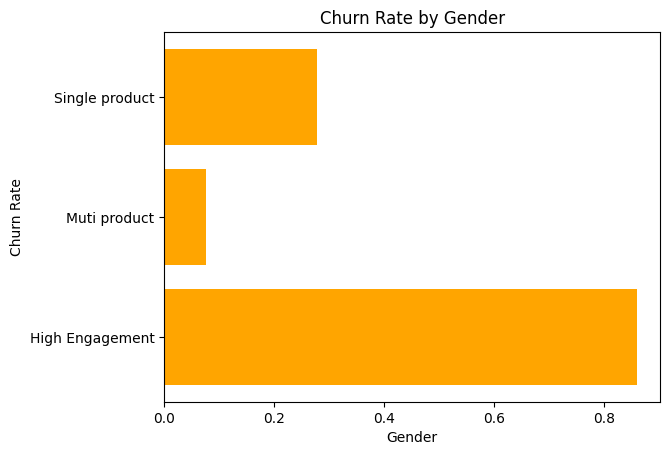

In [ ]:
products_category_churn=df.groupby('products_category')['churn'].mean()
print(products_category_churn)

plt.barh(products_category_churn.index,products_category_churn ,color='orange')
plt.title('Churn Rate by Gender')
plt.xlabel("Gender")
plt.ylabel("Churn Rate")
plt.show()

High Engagement customers have the highest churn rate, close to 90%, indicating a critical retention issue.
Single product customers show a moderate churn rate around 30%, suggesting opportunities for cross-selling.
Multi-product customers churn significantly less, showing higher loyalty and value stability.
Retention efforts should focus heavily on High Engagement customers to understand dissatisfaction and reduce churn.

In [ ]:
df.groupby('Balance_Category')['churn'].mean()

C:\Users\mrak5\AppData\Local\Temp\ipykernel_20168\3590171148.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Balance_Category')['churn'].mean()


Balance_Category
No balance    0.138236
Low           0.346667
Medium        0.238567
High          0.240490
Name: churn, dtype: float64

In [ ]:
df.groupby('tenure_group')['churn'].mean()

C:\Users\mrak5\AppData\Local\Temp\ipykernel_20168\3443130076.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_group')['churn'].mean()


tenure_group
New Customer    0.211412
Mid-Term        0.196446
Long-Term       0.204482
Name: churn, dtype: float64

In [ ]:
pd.crosstab(df['country'], df['churn'], normalize='index' ) * 100

churn,0,1
country,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


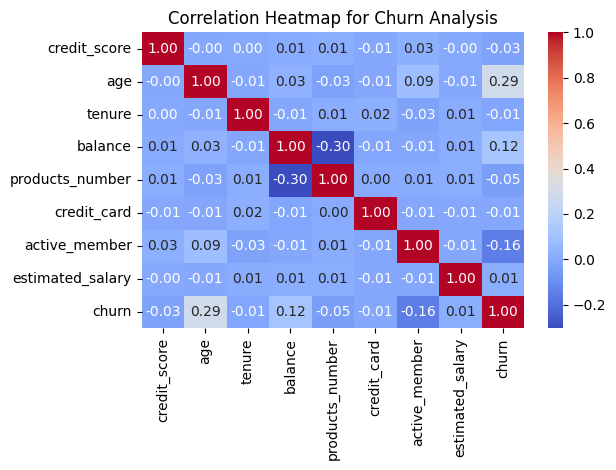

In [ ]:
numeicals_cols = ['credit_score','age','tenure','balance','products_number','credit_card','active_member','estimated_salary','churn']

corr = df[numeicals_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap for Churn Analysis")
plt.tight_layout()
plt.show()

Age shows the strongest positive correlation with churn (0.29), meaning older customers are more likely to leave.
Active members show a negative correlation with churn (-0.16), indicating engaged customers churn less.
Balance shows a small positive correlation (0.12), suggesting higher balance customers churn slightly more.
Credit score, tenure, salary, and number of products have very weak correlations, meaning they do not strongly influence churn.

In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,Age_Group,churn_out,Balance_Category,Credit_Score_Risk,tenure_group,products_category
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Yes,No balance,Medium Risk,New Customer,Single product
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,No,Medium,Medium Risk,New Customer,Single product
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,Yes,High,High Risk,Long-Term,High Engagement
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,No,No balance,Low Risk,New Customer,Muti product
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,No,High,Very Low Risk,New Customer,Single product


In [ ]:
df.groupby(['products_category','active_member'])['churn'].mean()

products_category  active_member
High Engagement    0                0.902174
                   1                0.802817
Muti product       0                0.098881
                   1                0.055601
Single product     0                0.366521
                   1                0.189231
Name: churn, dtype: float64

C:\Users\mrak5\AppData\Local\Temp\ipykernel_20168\536081673.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_data=df.groupby(['country','products_category','Age_Group'])['churn'].mean().reset_index()


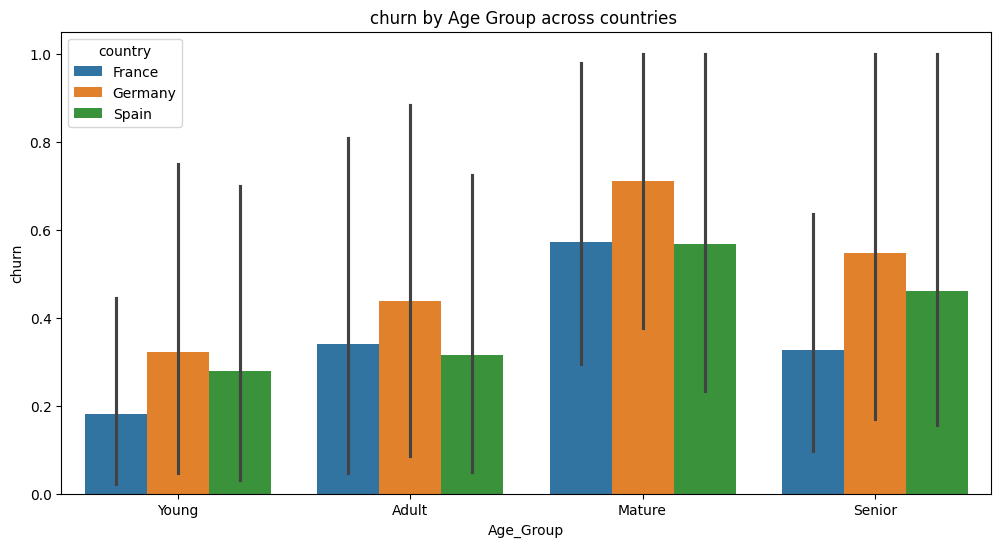

In [ ]:
churn_data=df.groupby(['country','products_category','Age_Group'])['churn'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=churn_data, x='Age_Group', y='churn', hue='country')
plt.title("churn by Age Group across countries ")
plt.show()


The bar chart visualizes the average churn rate across different age groups for three countries: France, Germany, and Spain. Each color represents a different country, while the height of the bars indicates the percentage of customers who churned in each age segment.

Key Observations

Germany consistently has the highest churn rate across all age groups.

The Mature age group shows the highest churn for all three countries.

Young customers have the lowest churn rates, suggesting higher loyalty or lower switching incentives.

France and Spain show similar churn patterns, both lower than Germany in every age category.

The largest risk segment is Mature customers in Germany, followed by Senior customers in Germany.

In [ ]:
df.groupby('Age_Group')['churn'].mean().reset_index().to_csv("churn_by_age_group.csv", index=False)

C:\Users\mrak5\AppData\Local\Temp\ipykernel_20168\3804303516.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['churn'].mean().reset_index().to_csv("churn_by_age_group.csv", index=False)


In [ ]:
# Save the Excel file
df.to_excel("Bank_Churnout_analysis.xlsx", index=False)